<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio_1_Spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Perceptron: Implementar el algoritmo del perceptron y entender por qué funciona.***

El perceptrón es el clasificador lineal binario más fundamental. Dado un vector de características $x \in \mathbb{R}^d$, el perceptrón predice una etiqueta $\hat{y} \in \{-1, +1\}$ según la regla de decisión $\hat{y} = \text{signo}(w^T x + b)$, donde $w$ es el vector de pesos y $b$ es el sesgo o bias.

### ¿Por qué funciona el algoritmo de aprendizaje?

El algoritmo entrena iterativamente ajustando los pesos solo cuando comete un error de clasificación. Para una muestra $(x_i, y_i)$ se tiene

- Si la predicción es correcta $\hat{y}_i = y_i$, no hay actualización, expresada como $y_i (w^T x_i + b) > 0$.
- Si la muestra es mal clasificada $y_i (w^T x_i + b) \le 0$, se realiza la actualización dada por
  
  $$w \leftarrow w + \eta \, y_i \, x_i$$
  $$b \leftarrow b + \eta \, y_i$$

Podemos interpretar de forma geométrica esto como sigue.

Cuando una muestra positiva, $y_i = +1$, es clasificada incorrectamente como negativa, significa que el producto escalar $w^T x_i$ es demasiado pequeño. Al sumar $\eta x_i$ a $w$, el nuevo vector de pesos $w'$ forma un ángulo más agudo con $x_i$, aumentando la puntuación $w'^T x_i$ hacia la región positiva. De manera análoga, para un error en una muestra negativa, $y_i = -1$, se resta $\eta x_i$, alejando el hiperplano del punto.

Si los datos son linealmente separables, el algoritmo encontrará un hiperplano separador en un número finito de pasos.

--- Pesos Aprendidos ---
Frec. Palabras Spam: 0.0650
Frec. Palabras Legítimas: -0.0600
Sesgo (Bias b): 0.0000

Predicción para el nuevo correo [0.1 0.8]: Legítimo (-1)


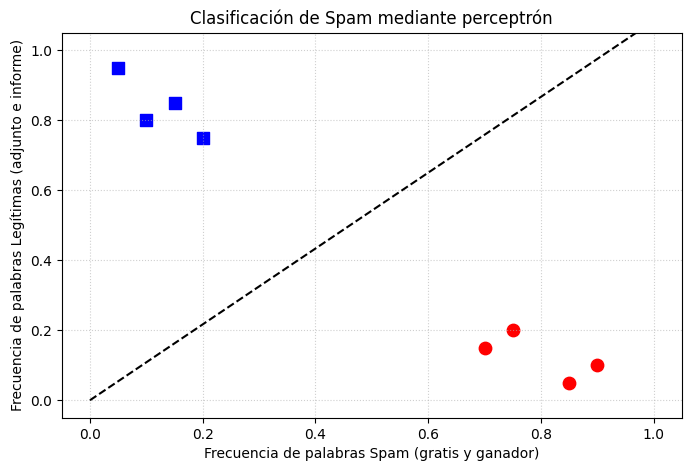

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                # Regla de activación
                linear_output = np.dot(xi, self.weights) + self.bias
                prediction = 1 if linear_output >= 0 else -1

                # Actualización de parámetros ante error
                if prediction != target:
                    update = self.lr * target
                    self.weights += update * xi
                    self.bias += update
                    errors += 1

            self.errors_history.append(errors)
            if errors == 0:
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

# Simulación con un dataset simplificado de detección de Spam

# Vocabulario de características
X_train = np.array([
    [0.85, 0.05],  # Correo Spam
    [0.90, 0.10],  # Correo Spam
    [0.70, 0.15],  # Correo Spam
    [0.10, 0.80],  # Correo Legítimo
    [0.05, 0.95],  # Correo Legítimo
    [0.20, 0.75],  # Correo Legítimo
    [0.75, 0.20],  # Correo Spam
    [0.15, 0.85]   # Correo Legítimo
])

# Etiquetas: +1 = Spam, -1 = Legítimo
y_train = np.array([1, 1, 1, -1, -1, -1, 1, -1])

# Entrenar el modelo
model = Perceptron(learning_rate=0.1, epochs=50)
model.fit(X_train, y_train)

# Resultados del entrenamiento
vocabulario = ["Frec. Palabras Spam", "Frec. Palabras Legítimas"]
print("--- Pesos Aprendidos ---")
for kw, w in zip(vocabulario, model.weights):
    print(f"{kw}: {w:.4f}")
print(f"Sesgo (Bias b): {model.bias:.4f}\n")

# Probar predicción con un mensaje nuevo
nuevo_correo = np.array([[0.10, 0.80]])
pred = model.predict(nuevo_correo)[0]
etiqueta = "Spam (+1)" if pred == 1 else "Legítimo (-1)"
print(f"Predicción para el nuevo correo {nuevo_correo[0]}: {etiqueta}")

# Visualización de la frontera de decisión
plt.figure(figsize=(8, 5))
for xi, yi in zip(X_train, y_train):
    color = 'red' if yi == 1 else 'blue'
    marker = 'o' if yi == 1 else 's'
    label = 'Spam' if yi == 1 else 'Legítimo'
    plt.scatter(xi[0], xi[1], color=color, marker=marker, s=80)

# Dibujar la línea de decisión w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
x1_vals = np.linspace(0, 1, 100)
if model.weights[1] != 0:
    x2_vals = -(model.weights[0] * x1_vals + model.bias) / model.weights[1]
    plt.plot(x1_vals, x2_vals, color='black', linestyle='--', label='Frontera de decisión')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Frecuencia de palabras Spam (gratis y ganador)')
plt.ylabel('Frecuencia de palabras Legítimas (adjunto e informe)')
plt.title('Clasificación de Spam mediante perceptrón')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

***Supongamos que usamos un perceptron para detectar mensajes de spam. Digamos que cada mensaje de correo electrónico está representado por la frecuencia de aparición de palabras clave y la salida es +1 si el mensaje se considera spam***

***1.   ¿Se te ocurren algunas palabras clave que terminen con un peso positivo grande en el perceptron?***

***2. ¿Qué hay de las palabras clave que obtendrán un peso negativo?***

***3. ¿Qué parámetro del perceptron afecta directamente a la cantidad de mensajes límite que terminan siendo clasificados como spam?***




1. Las palabras con pesos positivos son aquellas cuya presencia incrementa la probabilidad de que la suma ponderada $w^T x + b$ sea mayor que cero. Esto es, clasificar el mensaje como $+1$ o spam.
* **Ejemplos:** `"gratis"`, `"oferta"`, `"urgente"`, `"ganador"`, `"descuento"`, `"casino"`, `"cripto"`, `"transferencia"`, `"haz clic aquí"`

2. Las palabras con pesos negativos reducen la suma ponderada, actuando como indicativos de correo legítimo. Su presencia ayuda a descartar que el correo sea spam y su salida es $-1$.
* **Ejemplos:** `"reunión"`, `"adjunto"`, `"proyecto"`, `"informe"`, `"profesor"`, `"clase"`, `"cordialmente"`, `"factura"`, `"estimado"`

3. El sesgo afecta directamente el umbral de decisión. Se puede interpretar como sigue
* Un valor de $b$ más alto disminuye la exigencia para clasificar un mensaje como spam. La red responderá con $+1$ ante una menor presencia de palabras sospechosas.
* Un valor de $b$ más bajo requiere que el correo acumule un número significativo de palabras con pesos positivos para superar el umbral de cero, haciendo al filtro más conservador.